# 08d · GSE65391 · RNA_array · pvclust-py: patients, and the two-way figure (Python)

Reads `hub_matrix_first_visits.csv`, `hub_matrix_first_visits_annotations.csv` (notebook 07) and
`pvclust_genes.pkl` (notebook 08c). Writes the dendrogram and the two-way heatmap to `figures/GSE65391/`.

**Method and settings** as notebook 08c: pvclust (Suzuki and Shimodaira 2006) through pvclust-py,
`ward.D2` on Minkowski distance with p = 2, 1,000 replicates per scale, seed 20260928. No k.

**This axis is the weaker one, and the notebook says so.** Here the 157 patients are the objects
clustered, so the resampling units are the 140 genes. pvclust-py's documentation: resampling analytes
is "anti-conservative - analytes are co-expressed, not independent", so AU "comes out
ANTI-CONSERVATIVE, i.e. optimistic". The hub genes are by construction groups of co-expressed genes.
AU values on this axis are optimistic and are reported with that caveat.

## Load the matrix and annotations written by notebook 07

In [1]:
import pickle, warnings
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
from pvclust_py.core import pvclust, pvpick
from pvclust_py.plot import dendrogram, heatmap

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "endotypes-transcriptomics.yml").exists())
ART  = ROOT / "data" / "run_artifacts" / "GSE65391"
FIG  = ROOT / "figures" / "GSE65391"; FIG.mkdir(parents=True, exist_ok=True)
SEED = 20260928
pd.set_option("display.max_colwidth", None)   # show every cluster member

X   = pd.read_csv(ART / "hub_matrix_first_visits.csv", index_col=0)
ann = pd.read_csv(ART / "hub_matrix_first_visits_annotations.csv").set_index("sample").loc[X.index]
genes = pd.read_csv(ART / "hub_genes.csv").set_index("gene").loc[X.columns]
X.shape

(157, 140)

**Explanation**
- `pandas` holds tables in Python (McKinney W. Data structures for statistical computing in Python.
  *Proceedings of the 9th Python in Science Conference* 2010:56-61).
- The imports and `ROOT`, `ART`, `FIG` as in notebook 08c.
- `X`: the 157 first visits by 140 hub genes (notebook 07).
- `ann`: each child's stage, nephritis class and SLEDAI; `.set_index("sample").loc[X.index]` puts the rows
  in the order of `X`.
- `genes`: each hub gene's module, in the order of the columns of `X`.

## Run pvclust on the patients

In [2]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    res_p = pvclust(X, cluster="rows", method_dist="minkowski", method_hclust="ward.D2",
                    nboot=1000, seed=SEED)
for w in caught:
    print("pvclust-py warning:", w.message)

pvclust-py warning: clustering rows means resampling the 140 columns, which are typically correlated rather than independent draws; AU will be anti-conservative (optimistic). Fine for the companion dendrogram of a two-way figure -- just do not quote these p-values as if they were the column ones.


**Explanation**
- `pvclust(X, cluster="rows", ...)` clusters the rows, the 157 children, and resamples the columns, the
  genes. Settings as in notebook 08c.
- pvclust-py warns that on this axis AU is anti-conservative (too optimistic), because genes are correlated
  and are not independent draws. The loop prints its warnings.

## Pick the supported clusters

In [3]:
picked = pvpick(res_p, alpha=0.95)
sizes = sorted((len(e["members"]) for e in picked), reverse=True)
print(f"{len(picked)} patient clusters with AU >= 0.95 (anti-conservative on this axis); sizes: {sizes}")

16 patient clusters with AU >= 0.95 (anti-conservative on this axis); sizes: [9, 4, 4, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


**Explanation**
- `pvpick(res_p, alpha=0.95)` returns the largest non-overlapping clusters with AU of at least 0.95 (see
  notebook 08c).
- `sizes` lists their sizes, largest first.

In [4]:
pd.DataFrame([{"size": len(e["members"]), "AU": round(e["au"], 3), "BP": round(e["bp"], 3),
               "members": ", ".join(e["members"])} for e in picked]
             ).sort_values(["size", "AU"], ascending=False).reset_index(drop=True)

,size,AU,BP,members
0,9,0.975,0.033,"GSM1594435, GSM1594501, GSM1594554, GSM1594657, GSM1594662, GSM1594810, GSM1595001, GSM1595032, GSM1595185"
1,4,0.983,0.595,"GSM1594273, GSM1594378, GSM1594742, GSM1594837"
2,4,0.953,0.712,"GSM1594731, GSM1595153, GSM1595158, GSM1595217"
3,3,0.992,0.941,"GSM1595188, GSM1595203, GSM1595220"
4,3,0.960,0.862,"GSM1594634, GSM1594964, GSM1595082"
5,3,0.960,0.887,"GSM1594482, GSM1594640, GSM1595094"
6,2,0.999,0.997,"GSM1594394, GSM1595004"
7,2,0.996,0.874,"GSM1594526, GSM1594613"
8,2,0.995,0.987,"GSM1594573, GSM1595211"
9,2,0.993,0.955,"GSM1594556, GSM1595182"


**Explanation**
- One row per picked cluster: its size, AU, BP and members, the largest first. `sort_values(["size", "AU"])`
  sorts by size, then by AU.

**Result.** 16 patient clusters reach AU >= 0.95 (AU 0.953 to 0.999; BP 0.033 to 0.997), and even with the
optimistic AU of this axis they are small: one of 9 children (AU = 0.975, BP = 0.033), two of 4, three of 3
and ten of 2.

AU is the approximately unbiased p-value from the multiscale bootstrap; BP is the ordinary bootstrap probability, which is biased (Suzuki and Shimodaira 2006). A cluster with high AU and low BP is supported only after the multiscale correction.

## Draw the tree with AU and BP

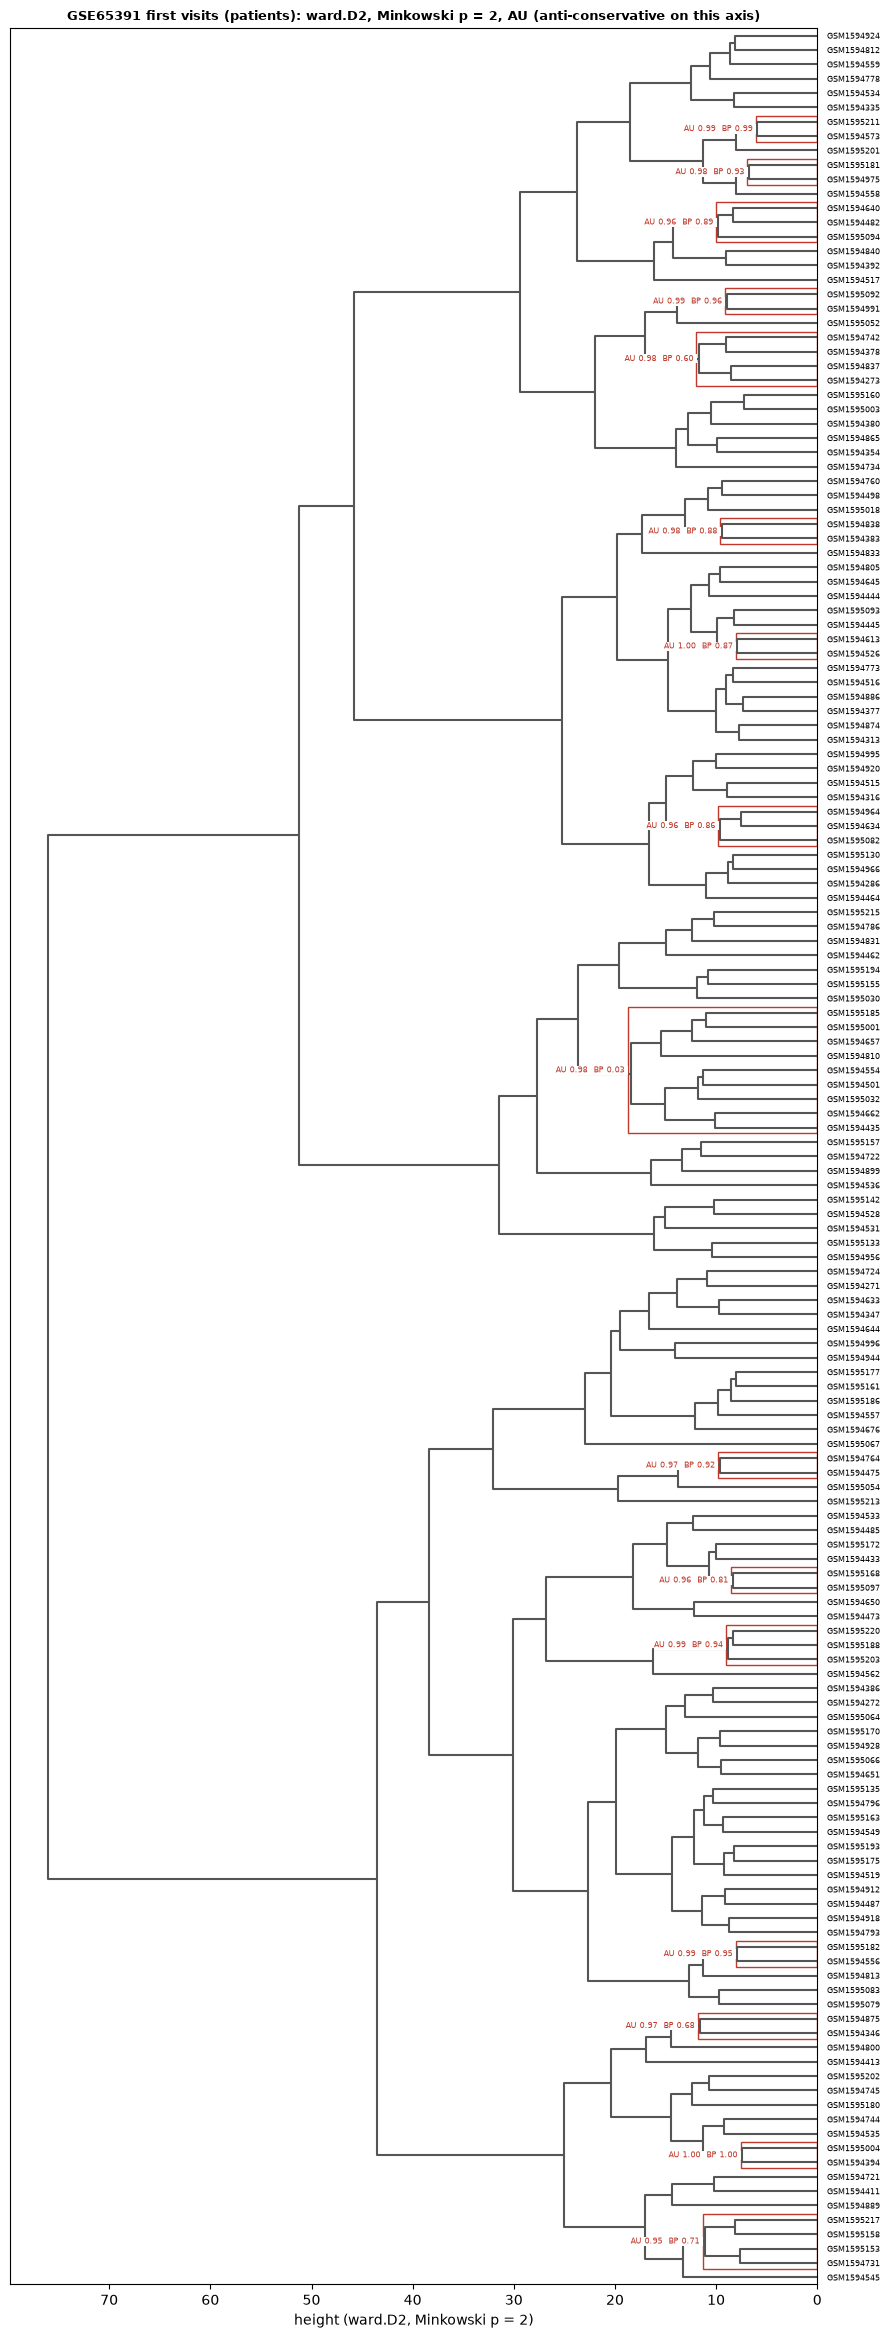

In [5]:
# The pvclust tree with every label shown. Each red box is one pvpick cluster (AU >= 0.95),
# labelled with its AU and BP values (AU: approximately unbiased; BP: ordinary bootstrap).
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.cluster.hierarchy import dendrogram as tree

def pv_figure(res, picked, leaf_text, title, path):
    n = len(res.labels)
    fig, ax = plt.subplots(figsize=(9, max(4, 0.14 * n + 1.5)))
    d = tree(res.linkage, labels=[leaf_text[l] for l in res.labels], orientation="left", ax=ax,
             color_threshold=0, above_threshold_color="#555555", leaf_font_size=6)
    pos = {res.labels[j]: 5 + 10 * k for k, j in enumerate(d["leaves"])}
    for e in picked:
        ys = [pos[m] for m in e["members"]]
        h = res.linkage[e["merge_order"] - 1, 2] * 1.02
        ax.add_patch(Rectangle((0, min(ys) - 4), h, max(ys) - min(ys) + 8, fill=False, edgecolor="#C0392B", lw=1))
        ax.text(h, (min(ys) + max(ys)) / 2, f"AU {e['au']:.2f}  BP {e['bp']:.2f} ", color="#C0392B",
                fontsize=6, ha="right", va="center",
                bbox=dict(facecolor="white", edgecolor="none", pad=0.3))
    ax.set_xlabel("height (ward.D2, Minkowski p = 2)")
    ax.set_title(title, fontsize=9, fontweight="bold")
    fig.tight_layout()
    fig.savefig(path, dpi=300)
    plt.show()

pv_figure(res_p, picked, {s: s for s in res_p.labels}, "GSE65391 first visits (patients): ward.D2, Minkowski p = 2, AU (anti-conservative on this axis)", FIG / "08d_GSE65391_RNA_array_pvclust_patients.png")

**Explanation**
- `matplotlib` draws the figure (Hunter JD. Matplotlib: a 2D graphics environment. *Comput Sci Eng*
  2007;9:90-95); `scipy.cluster.hierarchy.dendrogram` draws the tree from the linkage matrix (Virtanen P et
  al. SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nat Methods* 2020;17:261-272).
- `pv_figure()` as in notebook 08c, with each child labelled by its sample identifier.

**Two-way figure.** Patients as rows, genes as columns, each axis with its pvclust tree and red boxes
on clusters with AU >= 0.95; annotation strips for stage and nephritis. The matrix is already z-scored
per gene (notebook 07), so no further scaling is applied. Gene names are shown (up to 200 labels) with
each gene's WGCNA module as a strip.

## Two-way figure

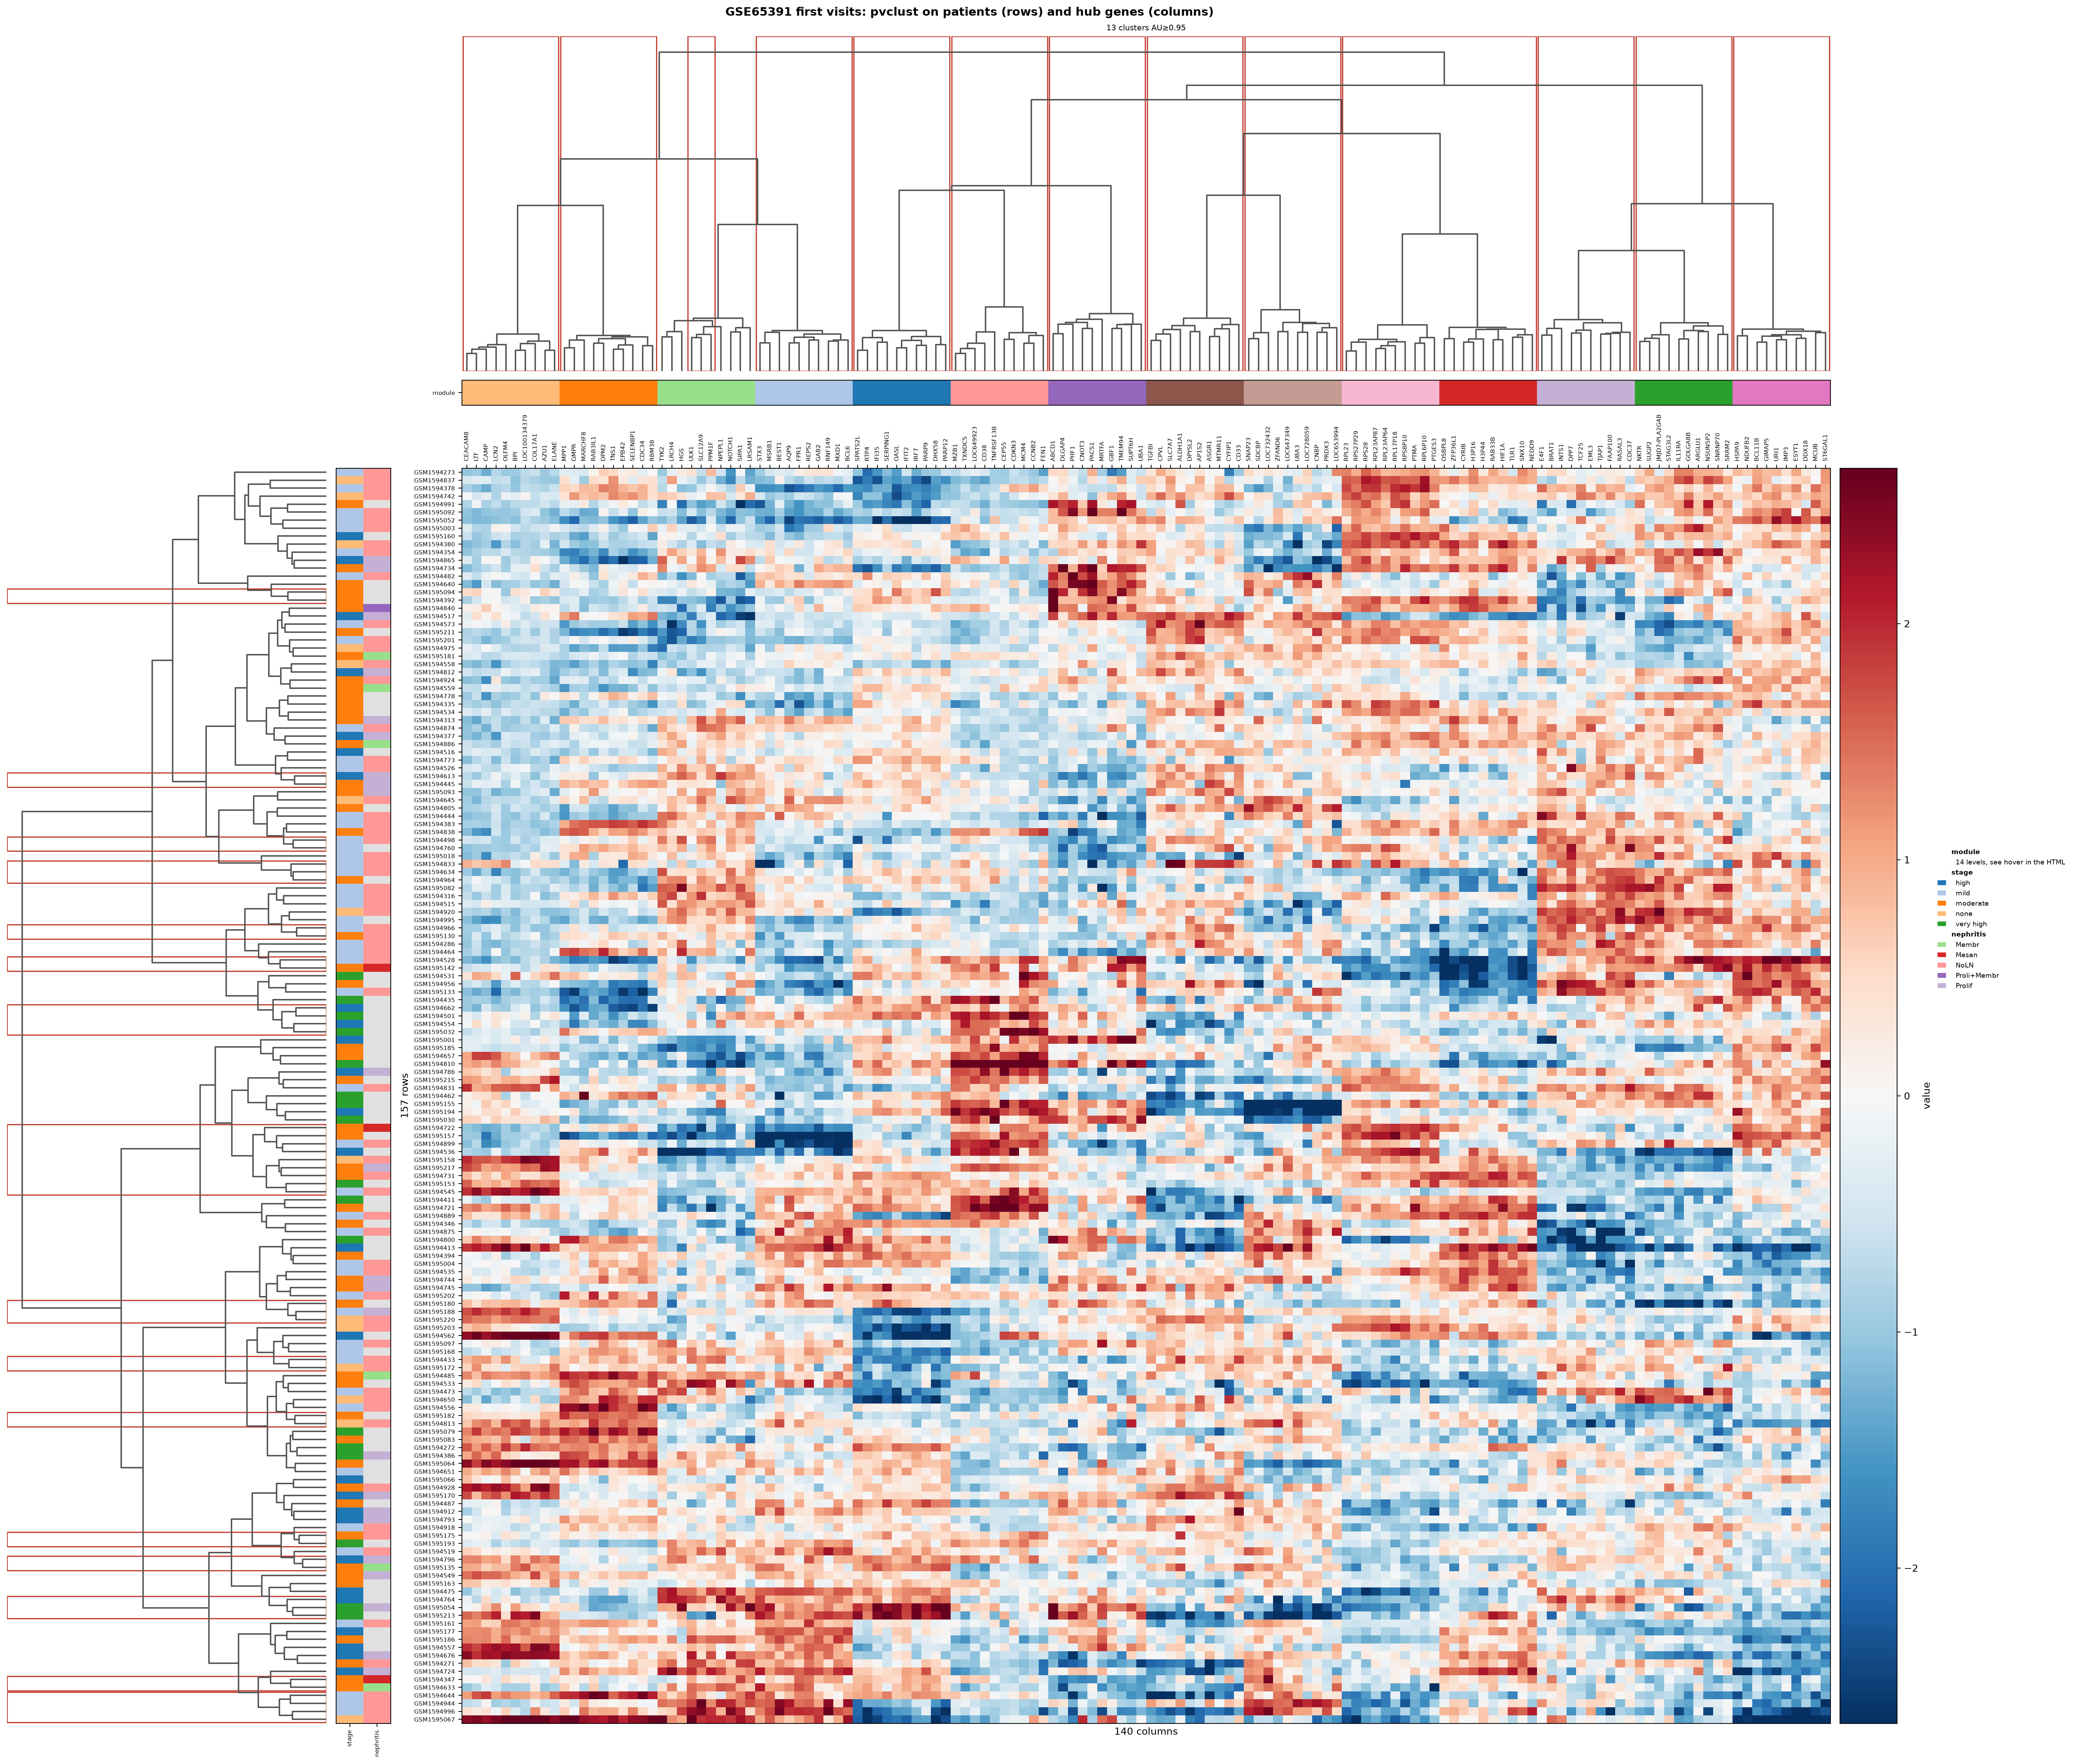

In [6]:
res_g = pickle.load(open(ART / "pvclust_genes.pkl", "rb"))
base2 = str(FIG / "08d_GSE65391_RNA_array_pvclust_two_way")
heatmap(X, base2, row_result=res_p, col_result=res_g, alpha=0.95,
        row_annotations=ann[["stage", "nephritis"]].fillna("NA"), col_annotations=genes[["module"]],
        z_score=None, max_labels=200,
        title="GSE65391 first visits: pvclust on patients (rows) and hub genes (columns)")
display(Image(base2 + ".png"))

**Explanation**
- `pickle.load()` reads the gene result saved by notebook 08c, so pvclust is not run again on the genes.
- `heatmap(X, base2, row_result=res_p, col_result=res_g, ...)` from pvclust-py draws the matrix with the
  patients' tree on the left and the genes' tree on top, red boxes on the clusters with AU of at least 0.95,
  strips for stage and nephritis on the left and for module on top. `z_score=None`: the values are already
  z-scored.